# Практическое задание №4

Используйте данные из файла **StudentPerformanceFactors.csv** с информацией о студентах.

[Источник](https://www.kaggle.com/datasets/lainguyn123/student-performance-factors/code)

В нём содержаться следующие переменные:


| Название переменной | Описание переменной
|:-------------------:|:------------------:|
| Hours_Studied | Number of hours spent studying per week |
| Attendance | Percentage of classes attended |
| Parental_Involvement | Level of parental involvement in the student's education (Low, Medium, High)|
| Access_to_Resources | Availability of educational resources (Low, Medium, High)|
| Extracurricular_Activities | Participation in extracurricular activities (Yes, No).
| Sleep_Hours | Average number of hours of sleep per night.
| Previous_Scores |	Scores from previous exams.
| Motivation_Level |	Student's level of motivation (Low, Medium, High).
| Internet_Access |	Availability of internet access (Yes, No).
| Tutoring_Sessions |	Number of tutoring sessions attended per month.
| Family_Income |	Family income level (Low, Medium, High).
| Teacher_Quality |	Quality of the teachers (Low, Medium, High).
| School_Type |	Type of school attended (Public, Private).
| Peer_Influence |	Influence of peers on academic performance (Positive, Neutral, Negative).
| Physical_Activity |	Average number of hours of physical activity per week.
| Learning_Disabilities |	Presence of learning disabilities (Yes, No).
| Parental_Education_Level |	Highest education level of parents (High School, College, Postgraduate).
| Distance_from_Home |	Distance from home to school (Near, Moderate, Far).
| Gender |	Gender of the student (Male, Female).
| Exam_Score |	Final exam score.


Выполните, пожалуйста, следующие задания.

##Задание 1

1. Используйте в качестве зависимой переменной при построении линейной регрессии переменную Exam_Score. Выберите не менее 3 категориальных и 3 метрических предикторов. Убедитесь, что не наблюдается высокой корреляции между метрическими предикторами, а категориальные предикторы не дублируют друг друга по значениям. Если наблюдается высокая корреляция между метрическими предикторами, то рассчитайте на их основе компоненты, используя метод главных компонент.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
import warnings
warnings.filterwarnings('ignore')

In [2]:
url = '/content/StudentPerformanceFactors.csv'

In [3]:
df = pd.read_csv(url)

In [4]:
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [5]:
df.shape

(6607, 20)

In [6]:
for t in df.dtypes.unique():
     print('Type: {}\n{}\n'.format(t, df.dtypes[df.dtypes==t].index.values))

Type: int64
['Hours_Studied' 'Attendance' 'Sleep_Hours' 'Previous_Scores'
 'Tutoring_Sessions' 'Physical_Activity' 'Exam_Score']

Type: object
['Parental_Involvement' 'Access_to_Resources' 'Extracurricular_Activities'
 'Motivation_Level' 'Internet_Access' 'Family_Income' 'Teacher_Quality'
 'School_Type' 'Peer_Influence' 'Learning_Disabilities'
 'Parental_Education_Level' 'Distance_from_Home' 'Gender']



In [7]:
df.info()
#проверим, по каким переменным есть пропущенные значения

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

Пропущенные значения есть по переменным Teacher_Quality, Parental_Education_Level, Distance_from_Home. Все переменные типа object.

In [8]:
df.isna().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


Из данной таблицы видно, что переменная Teacher_Quality содержит 78 пропущенных значений, переменная Parental_Education_Level - 90, Distance_from_Home - 67.

Из задания переменная Exam_Score - зависимая переменная. Является метрической переменной. Не содержит пропущенных значений.

<Axes: xlabel='Exam_Score', ylabel='Density'>

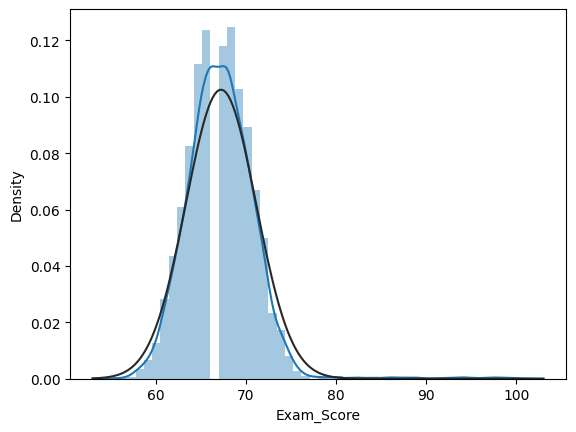

In [9]:
sns.distplot(df.Exam_Score, fit=stats.norm)

In [10]:
print('Skewness: {:.4f}'.format(df['Exam_Score'].skew()))
print('Kurtosis: {:.4f}'.format(df['Exam_Score'].kurt()))
print('Quartile Deviation: {:.4f}'.format((df['Exam_Score'].quantile(0.75) - df['Exam_Score'].quantile(0.25))/2))
print('Decile Ratio: {:.4f}'.format(df['Exam_Score'].quantile(0.9)/df['Exam_Score'].quantile(0.1)))

Skewness: 1.6448
Kurtosis: 10.5754
Quartile Deviation: 2.0000
Decile Ratio: 1.1429


In [11]:
df['Exam_Score'].describe()

,Exam_Score
count,6607.000000
mean,67.235659
std,3.890456
min,55.000000
25%,65.000000
50%,67.000000
75%,69.000000
max,101.000000


Проверим нормальность распреления через тест Колмогорова-Смирнова, так как выборка содержит больше 50 наблюдений.

H0: Распределение значений переменной Exam_Score статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной Exam_Score статистически значимо отличается от нормального распределения.

In [12]:
stats.kstest(df['Exam_Score'].dropna(), 'norm', args=(df['Exam_Score'].dropna().mean(), df['Exam_Score'].dropna().std()))

KstestResult(statistic=0.08172631627167026, pvalue=7.783849591914076e-39, statistic_location=68, statistic_sign=1)

In [13]:
print(7.783849591914076e-39 < 0.05)

True


Таким образом, p-value < 0.05, значит гипотеза H0 отвергается, что говорит о том, что распределение переменной Exam_Score статистически значимо отличается от нормального распределения.

Общий вывод по итогу предварительного анализа переменной: на основе анализа гистограммы и теста на нормальность можно констатировать, что распределение переменной статистически значимо отличается от нормального.

Наблюдается ассиметрия значений, но на основе гистограммы она не очень явная. Значение Skewness больше 0, можно сделать вывод о наличии небольшой ассиметрии в сторону меньших значений.
Распределение характеризуется пиковостью (высокое значение Kurtosis, сильно выше 3 при нормальном распределении).

Средний балл за экзамен - 67,2. 75% студентов получили балл до 69. Минимальная оценка - 55 баллов. Не наблюдается сильного отклонения значений от среднего (стандартное отклонение примерно равно 4). Децильное отношение составляет 1.14. Это означает, что 10% студентов с самыми высокими баллами получили в 1,14 раз более высокую оценку, чем 10% студентов с самыми низкими баллами.

####Метрические предикторы

Предварительно посмотрим уровень корреляции между метрическими переменными датасета. Построена тепловая матрица с коэффициентами корреляции Пирсона, чтобы можно было сделать предварительный вывод о том, между какими переменными можно наблюдать более сильную взаимосвязь. Преимущественно между всеми переменными низкая корреляция.

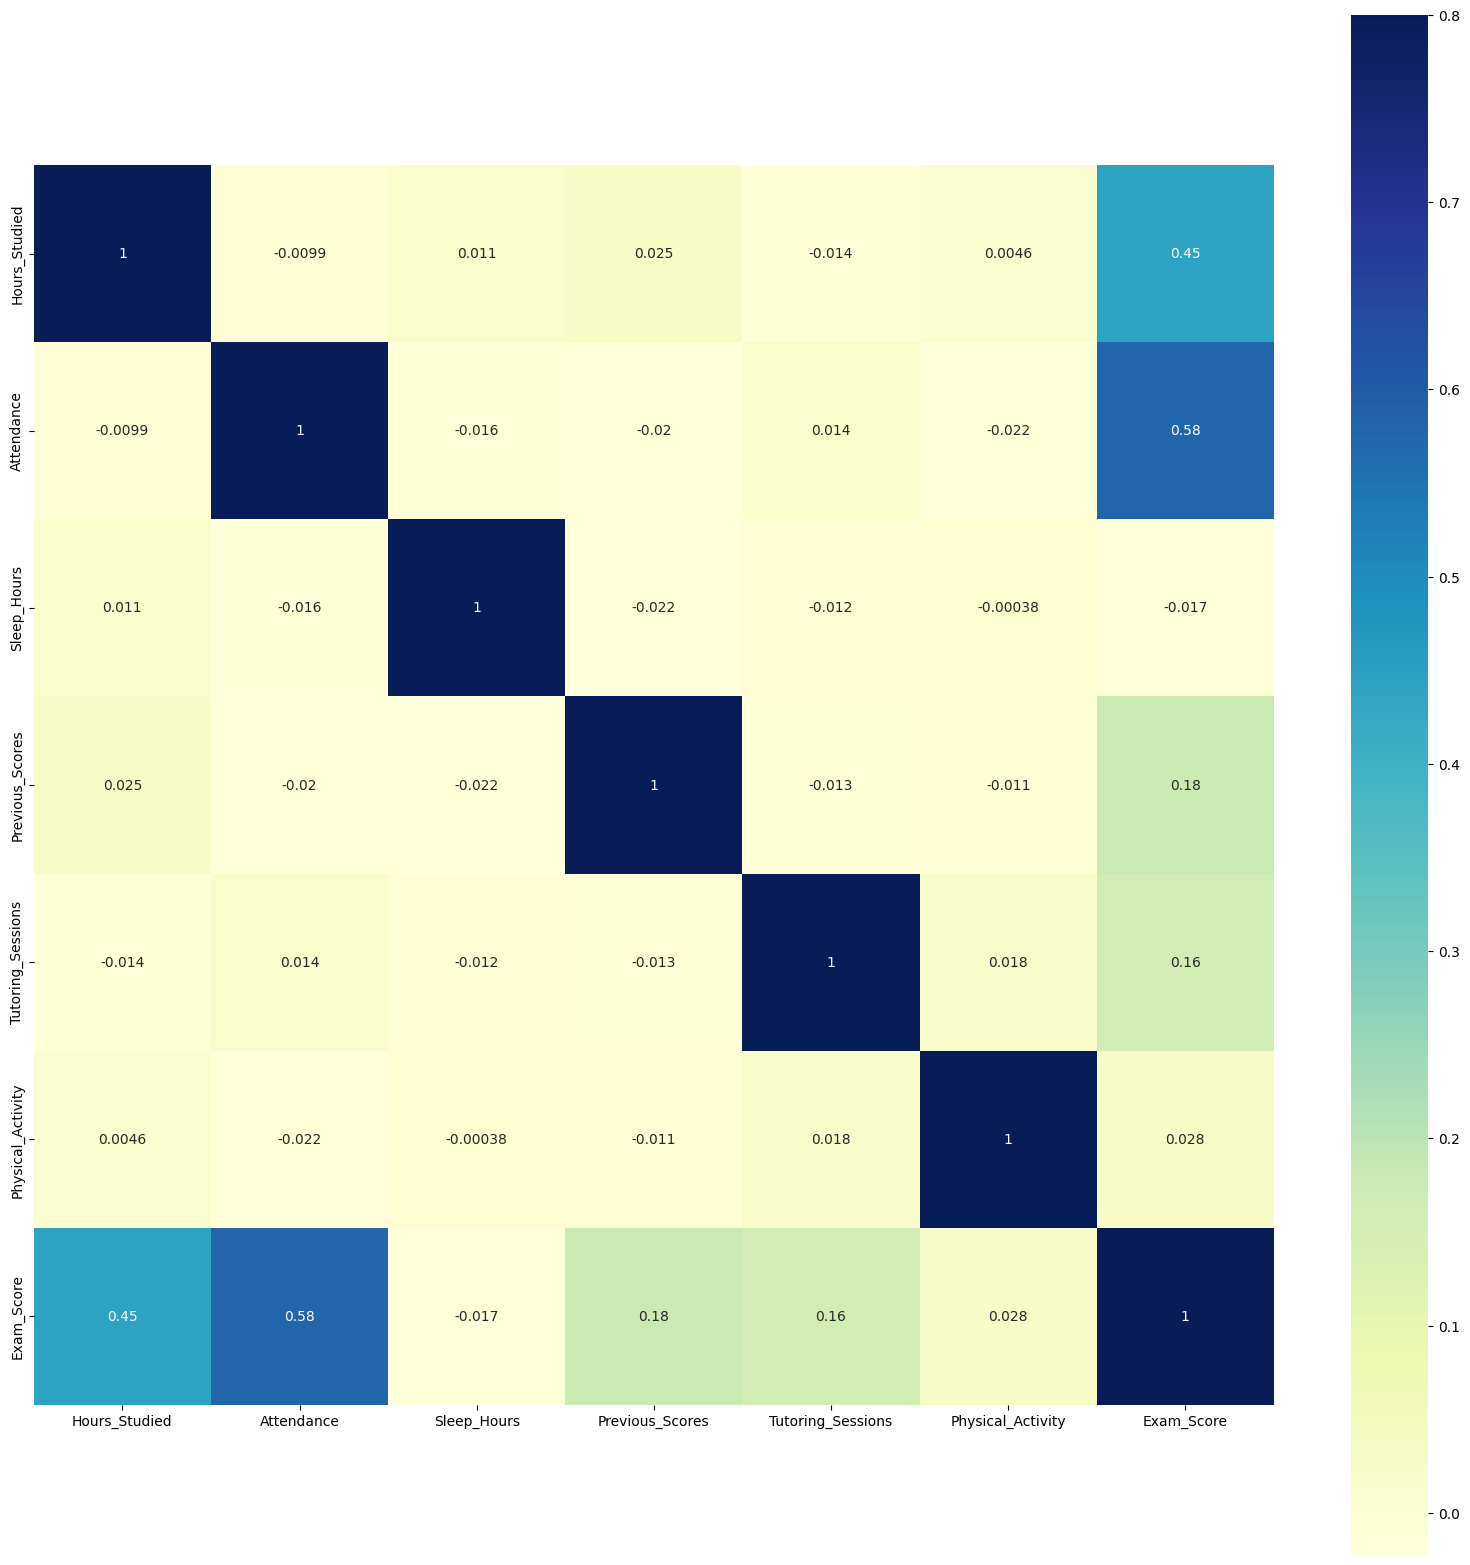

In [14]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(20, 20))
sns.heatmap(corr, vmax=.8, square=True, cmap='YlGnBu', annot=True)
plt.show()

Наиболее высокая корреляция между переменными Exam_Score и Hours_Studied, Exam_Score и Attendance, Exam_Score и Previous_Scores, Exam_Score и Tutoring_Sessions. Это подтверждает тепловая диаграмма ниже, которая наглядно показывает, с какими переменными у зависимой наибольшая корреляция по модулю.

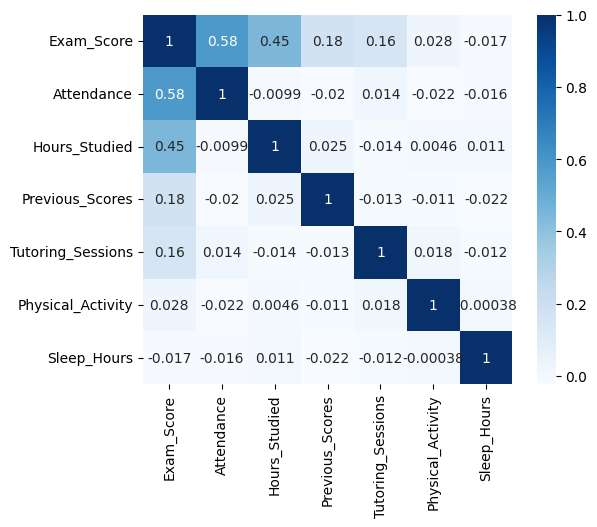

In [15]:
import numpy as np #10 самых высоких корреляций с Exam_Score
cols = corr.nlargest(10, 'Exam_Score').index
sns.heatmap(np.corrcoef(df[cols].values.T), square=True,
            yticklabels=cols.values, xticklabels=cols.values, cmap='Blues', annot=True)
plt.show()

In [16]:
df.corrwith(df['Exam_Score'], numeric_only=True).sort_values(ascending=False)
#коэффициенты корреляции с зависимой переменной в порядке убывания

,0
Exam_Score,1.000000
Attendance,0.581072
Hours_Studied,0.445455
Previous_Scores,0.175079
Tutoring_Sessions,0.156525
Physical_Activity,0.027824
Sleep_Hours,-0.017022


Проанализируем корреляцию между парами переменных.

**Переменные Exam_Score и Hours_Studied**

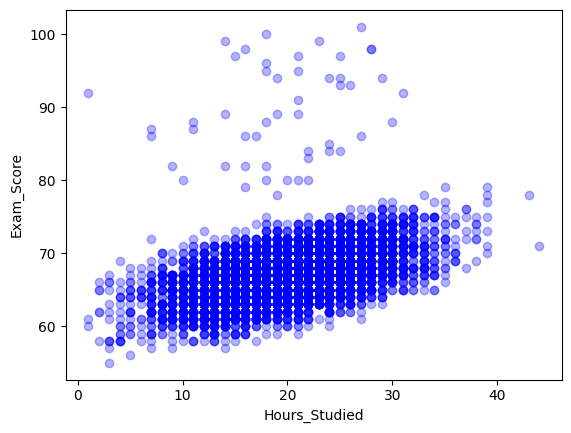

In [17]:
plt.scatter(df.Hours_Studied, df.Exam_Score, c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('Hours_Studied')
plt.ylabel('Exam_Score')
plt.show()

**Переменные Exam_Score и Attendance**

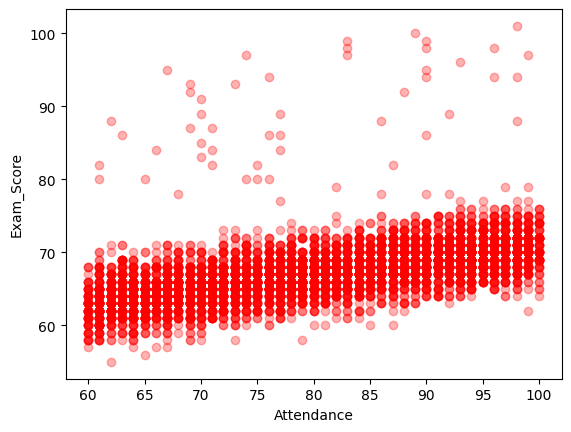

In [18]:
plt.scatter(df.Attendance, df.Exam_Score, c = 'red', marker = 'o', alpha=0.3)
plt.xlabel('Attendance')
plt.ylabel('Exam_Score')
plt.show()

**Переменные Exam_Score и Previous_Scores**

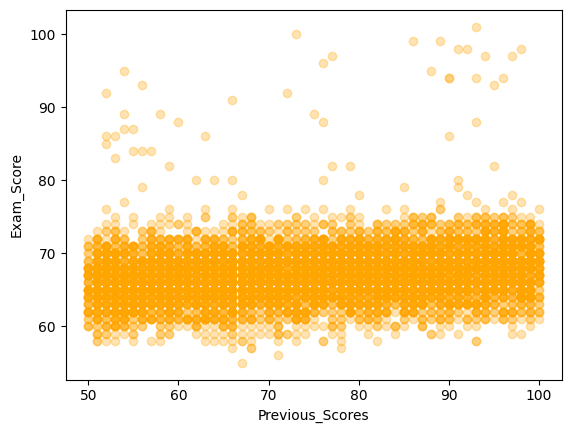

In [19]:
plt.scatter(df.Previous_Scores, df.Exam_Score, c = 'orange', marker = 'o', alpha=0.3)
plt.xlabel('Previous_Scores')
plt.ylabel('Exam_Score')
plt.show()

 Из 3 первых диаграмм рассеивания заметно, что есть довольно большое количество выбросов, поэтому для построения более точной регрессионной модели на следующих этапах будет необходимо очистить данные от выбросов. Далее посмотрим и сравним случаи, когда регрессионная модель была построена с выбросами и после их удаления.

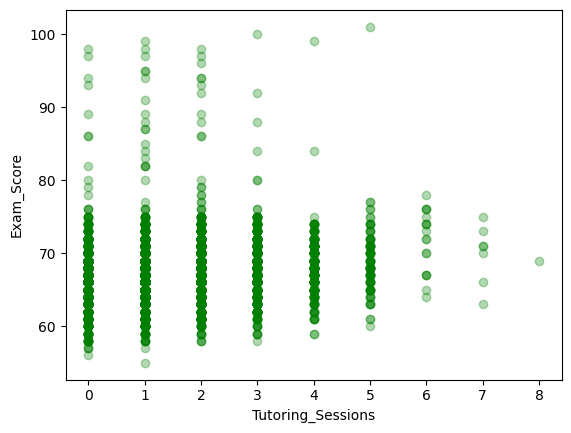

In [20]:
plt.scatter(df.Tutoring_Sessions, df.Exam_Score, c = 'green', marker = 'o', alpha=0.3)
plt.xlabel('Tutoring_Sessions')
plt.ylabel('Exam_Score')
plt.show() #переменная Tutoring_Sessions не метрическая

In [21]:
df['Tutoring_Sessions'].value_counts() #переменная не метрическая
#можно добавить в модель путем создания дамми-переменных

,count
Tutoring_Sessions,
1,2179
2,1649
0,1513
3,836
4,301
5,103
6,18
7,7
8,1


In [22]:
df['Tutoring_Sessions']=df['Tutoring_Sessions'].replace(8, 7)

In [23]:
df['Tutoring_Sessions']=df['Tutoring_Sessions'].replace(7, 6)

In [24]:
df['Tutoring_Sessions'].value_counts()
#в выборке есть только 1 наблюдение при 8 часах занятий с репетитором, 7 наблюдений при 7 часах
#добавим эти наблюдения к группе с 6 часами занятий

,count
Tutoring_Sessions,
1,2179
2,1649
0,1513
3,836
4,301
5,103
6,26


Вывод на основе корреляционного анализа зависимой переменной с метрическими переменными:

Переменная Hours_Studied: Количество часов, уделенное учебе, имеет самую высокую корреляцию с зависимой переменной. Во многом оценка за экзамен определяется количеством часов, которое потратил студент на обучение. Можно констатировать положительную корреляцию. Чем больше студент учился по времени, чем выше его оценка.

Сравнительно высокая корреляция зависимой переменной с переменной Attendance. Положительная взаимосвязь. Оценка также определяется посещаемостью занятий.

следующая по уровню корреляция с зависимой переменной у переменной Previous_Scores. Текущий результат экзамена также определяется предыдущим.

Есть корреляция между зависимой переменной и переменной Tutoring_Sessions. Но на основе диаграммы рассеяния можно сделать вывод, что переменная Tutoring_Sessions не является метрической, ее нельзя добавить в модель в качестве метрической. Рассмотрим ее отдельно.

Таким образом, возьмю в модель 3 количественных предиктора - Hours_Studied, Attendance, Previous_Scores. Корреляция с другими метрическими переменными очень низкая.

**Корреляция между предикторами**

In [25]:
df[['Hours_Studied','Attendance','Previous_Scores']].corr()

,Hours_Studied,Attendance,Previous_Scores
Hours_Studied,1.000000,-0.009908,0.024846
Attendance,-0.009908,1.000000,-0.020186
Previous_Scores,0.024846,-0.020186,1.000000


Между меторическими предикторами нет высокой корреляции. Значит, не создастся проблемы мультиколлинеарности.

####Категориальные предикторы

Еще раз выводим список переменных типа object

In [26]:
df.dtypes[df.dtypes== 'object'].index.values

array(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level',
       'Internet_Access', 'Family_Income', 'Teacher_Quality',
       'School_Type', 'Peer_Influence', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender'],
      dtype=object)

Предположим, какие переменные логически могут иметь влияние на текущую оценку за экзамен. Интересно будет посмотреть на переменные Access_to_Resources, Family_Income, Motivation_Level, Teacher_Quality, Gender. Проведем дополнительный анализ путем построения таблиц и ящиков с усами, чтобы сделать вывод, есть ли какая-то взаимосвязь меджу ними и зависимой переменной Exam_Score. Также рассмотрим здесь переменную Tutoring_Sessions.

In [27]:
df.pivot_table(index=['Motivation_Level'], values=['Exam_Score'], aggfunc=['mean']).round(2)

,mean
,Exam_Score
Motivation_Level,
High,67.70
Low,66.75
Medium,67.33


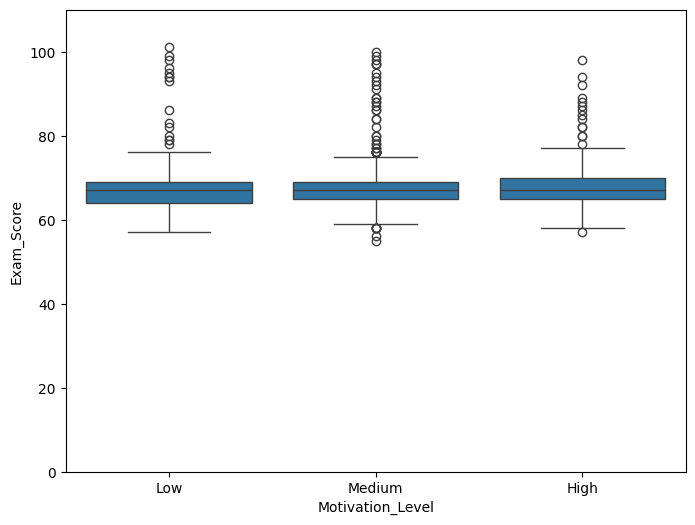

In [28]:
plt.figure(figsize=(8, 6))
fig = sns.boxplot(x=df['Motivation_Level'], y='Exam_Score',
                  data=pd.concat([df['Motivation_Level'], df['Exam_Score']], axis=1))
fig.axis(ymin=0, ymax=110)
plt.show()

Можно отметить, что с ростом уровня мотивации к учебе в среднем выше результаты экзамена. Можно проследить логическую зависимость.  

In [29]:
df.pivot_table(index=['Teacher_Quality'], values=['Exam_Score'], aggfunc=['mean', 'max', 'min']).round(2)

,mean,max,min
,Exam_Score,Exam_Score,Exam_Score
Teacher_Quality,,,
High,67.68,101,58
Low,66.75,94,58
Medium,67.11,100,55


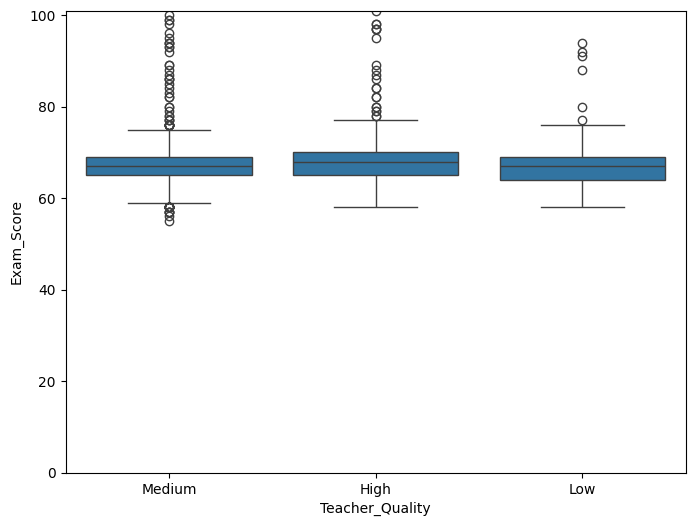

In [30]:
plt.figure(figsize=(8, 6))
fig = sns.boxplot(x=df['Teacher_Quality'], y='Exam_Score',
                  data=pd.concat([df['Exam_Score'], df['Teacher_Quality']], axis=1))
fig.axis(ymin=0, ymax=101)
plt.show()

В среднем нет разницы между баллами, которые получили студенты за экзамен при среднем и высоком уровне преподавания.

In [31]:
df.pivot_table(index=['Access_to_Resources'], values=['Exam_Score'], aggfunc=['mean', 'max', 'min']).round(2)

,mean,max,min
,Exam_Score,Exam_Score,Exam_Score
Access_to_Resources,,,
High,68.09,99,56
Low,66.20,98,55
Medium,67.13,101,58


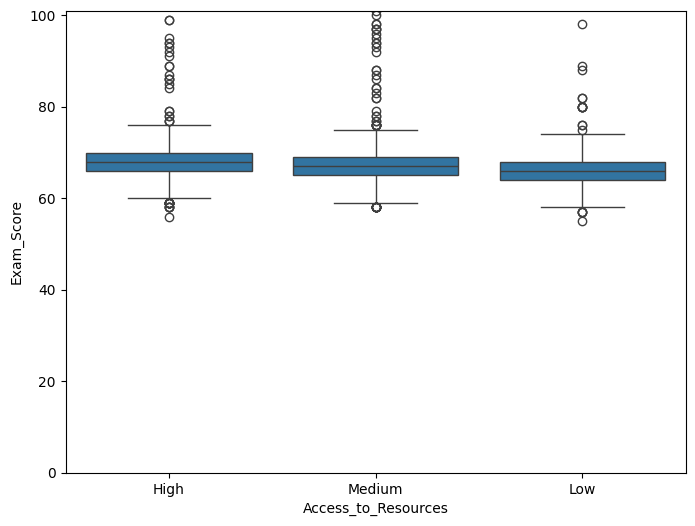

In [32]:
plt.figure(figsize=(8, 6))
fig = sns.boxplot(x=df['Access_to_Resources'], y='Exam_Score',
                  data=pd.concat([df['Exam_Score'], df['Access_to_Resources']], axis=1))
fig.axis(ymin=0, ymax=101)
plt.show()

In [33]:
df.pivot_table(index=['Family_Income'], values=['Exam_Score'], aggfunc=['mean', 'max', 'min']).round(2)

,mean,max,min
,Exam_Score,Exam_Score,Exam_Score
Family_Income,,,
High,67.84,101,58
Low,66.85,97,55
Medium,67.33,99,57


Можно отметить различия в среднем, максимальном и минимальном баллах за экзамен в зависимости от уровня дохода семьи. Чем выше уровень дохода, тем выше и эти значения.

In [34]:
df.pivot_table(index=['Gender'], values=['Exam_Score'], aggfunc=['mean', 'max', 'min']).round(2)

,mean,max,min
,Exam_Score,Exam_Score,Exam_Score
Gender,,,
Female,67.24,101,57
Male,67.23,99,55


Стоит отметить, что в среднем нет значимых различий между тем, как экзамен написали девушки и молодые люди. Есть небольшие различия в максимальной и минимальной оценке в пользу девушек. В модель данную переменную включать может быть не интересно.

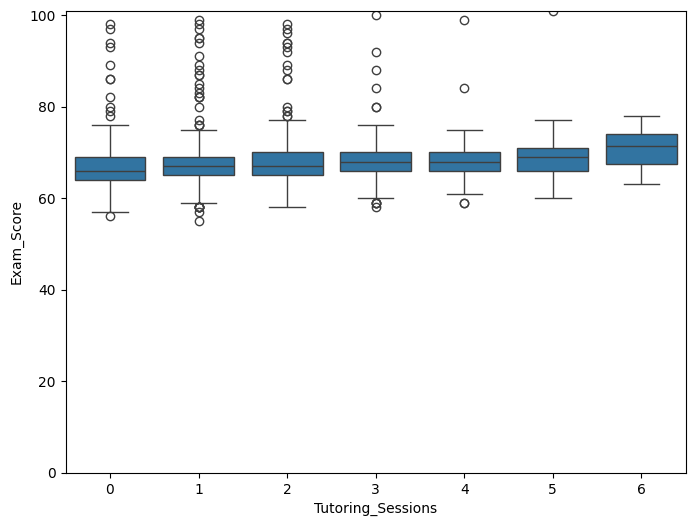

In [35]:
plt.figure(figsize=(8, 6))
fig = sns.boxplot(x=df['Tutoring_Sessions'], y='Exam_Score',
                  data=pd.concat([df['Exam_Score'], df['Tutoring_Sessions']], axis=1))
fig.axis(ymin=0, ymax=101)
plt.show()

Можно проследить, что при увеличении количества часов занятий у репетитора, в среднем больше и результат за экзамен. То есть можно предположить наличие зависимости Exam_Score от данной категориальной переменной.

В модель возьмем переменные: **Motivation_Level, Family_Income, Tutoring_Sessions, Access_to_Resources**. Теперь преобразуем их в дамми-переменные.



In [36]:
df['Motivation_Level'].value_counts()
#Motivation_Level - уровень мотивации к обучению. Группа Medium наиболее многочисленная, возьмем ее за референтную

,count
Motivation_Level,
Medium,3351
Low,1937
High,1319


In [37]:
MtvnLv_dummies=pd.get_dummies(df.Motivation_Level, prefix='Motivation_Level', prefix_sep='_', dtype=int)
MtvnLv_dummies.head(50) #Motivation_Level_Medium - референтная

,Motivation_Level_High,Motivation_Level_Low,Motivation_Level_Medium
0,0,1,0
1,0,1,0
2,0,0,1
3,0,0,1
4,0,0,1
5,0,0,1
6,0,1,0
7,0,0,1
8,1,0,0
9,0,0,1


In [38]:
df2 = pd.concat([df, MtvnLv_dummies], axis=1)
df2
#в df2 буду помещать все создаваемые дамми-переменные

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Motivation_Level_High,Motivation_Level_Low,Motivation_Level_Medium
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Positive,3,No,High School,Near,Male,67,0,1,0
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Negative,4,No,College,Moderate,Female,61,0,1,0
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Neutral,4,No,Postgraduate,Near,Male,74,0,0,1
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Negative,4,No,High School,Moderate,Male,71,0,0,1
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,Neutral,4,No,College,Near,Female,70,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,...,Positive,2,No,High School,Near,Female,68,0,0,1
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,...,Positive,2,No,High School,Near,Female,69,0,0,1
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,Negative,2,No,Postgraduate,Near,Female,68,0,1,0
6605,10,86,High,High,Yes,6,91,High,Yes,2,...,Positive,3,No,High School,Far,Female,68,1,0,0


In [39]:
df['Family_Income'].value_counts()
#возьмем за референтную среднюю, будем сравнивать с ней

,count
Family_Income,
Low,2672
Medium,2666
High,1269


In [40]:
FamIn_dummies=pd.get_dummies(df.Family_Income, prefix='Family_Income', prefix_sep='_', dtype=int)
FamIn_dummies.head(20)

,Family_Income_High,Family_Income_Low,Family_Income_Medium
0,0,1,0
1,0,0,1
2,0,0,1
3,0,0,1
4,0,0,1
5,0,0,1
6,0,1,0
7,1,0,0
8,0,0,1
9,1,0,0


In [41]:
df2 = pd.concat([df2, FamIn_dummies], axis=1)
df2 #Family_Income_Medium

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Motivation_Level_High,Motivation_Level_Low,Motivation_Level_Medium,Family_Income_High,Family_Income_Low,Family_Income_Medium
0,23,84,Low,High,No,7,73,Low,Yes,0,...,High School,Near,Male,67,0,1,0,0,1,0
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,College,Moderate,Female,61,0,1,0,0,0,1
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Postgraduate,Near,Male,74,0,0,1,0,0,1
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,High School,Moderate,Male,71,0,0,1,0,0,1
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,College,Near,Female,70,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,...,High School,Near,Female,68,0,0,1,1,0,0
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,...,High School,Near,Female,69,0,0,1,0,1,0
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,Postgraduate,Near,Female,68,0,1,0,0,1,0
6605,10,86,High,High,Yes,6,91,High,Yes,2,...,High School,Far,Female,68,1,0,0,0,1,0


In [42]:
df['Access_to_Resources'].value_counts()
#за референтную - Medium, самая многочисленная

,count
Access_to_Resources,
Medium,3319
High,1975
Low,1313


In [43]:
AccRes_dummies=pd.get_dummies(df.Access_to_Resources, prefix='Access_to_Resources', prefix_sep='_', dtype=int)
AccRes_dummies.head(20)

,Access_to_Resources_High,Access_to_Resources_Low,Access_to_Resources_Medium
0,1,0,0
1,0,0,1
2,0,0,1
3,0,0,1
4,0,0,1
5,0,0,1
6,0,1,0
7,1,0,0
8,1,0,0
9,0,0,1


In [44]:
df2 = pd.concat([df2, AccRes_dummies], axis=1)
df2 #Access_to_Resources_Medium - референтная

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Exam_Score,Motivation_Level_High,Motivation_Level_Low,Motivation_Level_Medium,Family_Income_High,Family_Income_Low,Family_Income_Medium,Access_to_Resources_High,Access_to_Resources_Low,Access_to_Resources_Medium
0,23,84,Low,High,No,7,73,Low,Yes,0,...,67,0,1,0,0,1,0,1,0,0
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,61,0,1,0,0,0,1,0,0,1
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,74,0,0,1,0,0,1,0,0,1
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,71,0,0,1,0,0,1,0,0,1
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,70,0,0,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,...,68,0,0,1,1,0,0,0,0,1
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,...,69,0,0,1,0,1,0,0,0,1
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,68,0,1,0,0,1,0,0,1,0
6605,10,86,High,High,Yes,6,91,High,Yes,2,...,68,1,0,0,0,1,0,1,0,0


In [45]:
df['Tutoring_Sessions'].value_counts()
#за референтную возьму группу с количеством посещенных занятий с репетитором равным 1

,count
Tutoring_Sessions,
1,2179
2,1649
0,1513
3,836
4,301
5,103
6,26


In [46]:
TutorSes_dummies=pd.get_dummies(df.Tutoring_Sessions, prefix='Tutoring_Sessions', prefix_sep='_', dtype=int)
TutorSes_dummies.head(20)

,Tutoring_Sessions_0,Tutoring_Sessions_1,Tutoring_Sessions_2,Tutoring_Sessions_3,Tutoring_Sessions_4,Tutoring_Sessions_5,Tutoring_Sessions_6
0,1,0,0,0,0,0,0
1,0,0,1,0,0,0,0
2,0,0,1,0,0,0,0
3,0,1,0,0,0,0,0
4,0,0,0,1,0,0,0
5,0,0,0,1,0,0,0
6,0,1,0,0,0,0,0
7,0,1,0,0,0,0,0
8,1,0,0,0,0,0,0
9,1,0,0,0,0,0,0


In [47]:
df2 = pd.concat([df2, TutorSes_dummies], axis=1)
df2 #Tutoring_Sessions_1 - референтная

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Access_to_Resources_High,Access_to_Resources_Low,Access_to_Resources_Medium,Tutoring_Sessions_0,Tutoring_Sessions_1,Tutoring_Sessions_2,Tutoring_Sessions_3,Tutoring_Sessions_4,Tutoring_Sessions_5,Tutoring_Sessions_6
0,23,84,Low,High,No,7,73,Low,Yes,0,...,1,0,0,1,0,0,0,0,0,0
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,0,0,1,0,0,1,0,0,0,0
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,0,0,1,0,0,1,0,0,0,0
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,0,0,1,0,1,0,0,0,0,0
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,...,0,0,1,0,1,0,0,0,0,0
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,...,0,0,1,0,0,0,1,0,0,0
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,0,1,0,0,0,0,1,0,0,0
6605,10,86,High,High,Yes,6,91,High,Yes,2,...,1,0,0,0,0,1,0,0,0,0


In [48]:
df2.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score', 'Motivation_Level_High', 'Motivation_Level_Low',
       'Motivation_Level_Medium', 'Family_Income_High', 'Family_Income_Low',
       'Family_Income_Medium', 'Access_to_Resources_High',
       'Access_to_Resources_Low', 'Access_to_Resources_Medium',
       'Tutoring_Sessions_0', 'Tutoring_Sessions_1', 'Tutoring_Sessions_2',
       'Tutoring_Sessions_3', 'Tutoring_Sessions_4', 'Tutoring_Sessions_5',
       'Tutoring_Sessions_6'],
      dtype='object')

##Задание 2

2. Постройте модель множественной линейной регрессии использовав в качестве предикторов исходные метрические переменные или рассчитанные на их основе компоненты и категориальные предикторы. Напишите уравнение регрессии. Оцените характеристики регрессионной модели в целом.

В предыдущем задании были выбраны метрические и категориальные предикторы для построения модели множественной регрессии.

Метрические предикторы: Hours_Studied, Attendance, Previous_Scores.

Категориальные предикторы (по которым уже были созданы дамми-переменные): Motivation_Level, Family_Income, Tutoring_Sessions, Access_to_Resources.

Референтные переменные: Tutoring_Sessions_1, Motivation_Level_Medium, Access_to_Resources_Medium, Family_Income_Medium, Access_to_Resources_Medium.

###Множественная линейная регрессия

In [49]:
import statsmodels.api as sm

In [50]:
df_model1 = df2.dropna(subset=['Exam_Score', 'Attendance', 'Hours_Studied', 'Previous_Scores', 'Motivation_Level_High', 'Motivation_Level_Low','Family_Income_High', 'Family_Income_Low', 'Access_to_Resources_High','Access_to_Resources_Low', 'Tutoring_Sessions_0', 'Tutoring_Sessions_2',
       'Tutoring_Sessions_3', 'Tutoring_Sessions_4', 'Tutoring_Sessions_5',
       'Tutoring_Sessions_6'])
df_model1.shape

(6607, 36)

In [51]:
x_mult = df_model1[['Hours_Studied', 'Previous_Scores', 'Attendance', 'Motivation_Level_High', 'Motivation_Level_Low','Family_Income_High', 'Family_Income_Low', 'Access_to_Resources_High','Access_to_Resources_Low', 'Tutoring_Sessions_0', 'Tutoring_Sessions_2',
       'Tutoring_Sessions_3', 'Tutoring_Sessions_4', 'Tutoring_Sessions_5',
       'Tutoring_Sessions_6']]
y = df_model1['Exam_Score']
x_mult_constant = sm.add_constant(x_mult)

In [52]:
model1 = sm.OLS(y, x_mult_constant).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.646
Method:                 Least Squares   F-statistic:                     805.9
Date:                Thu, 13 Mar 2025   Prob (F-statistic):               0.00
Time:                        16:18:51   Log-Likelihood:                -14909.
No. Observations:                6607   AIC:                         2.985e+04
Df Residuals:                    6591   BIC:                         2.996e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

####Характеристика модели

Выведем и проведем оценку всех наиболее важных параметров получившейся модели.

In [53]:
print('R^2 = {:f}'.format(model1.rsquared))
print('Adj. R^2 = {:f}'.format(model1.rsquared_adj)) #функция из модуля statsmodels
print('F-test significance = {:f}'.format(model1.f_pvalue))

R^2 = 0.647165
Adj. R^2 = 0.646362
F-test significance = 0.000000


R^2 позволяет оценить качество модели, насколько она хорошо подходит к данным. Коэффициент R^2 модели довольно высокий (выше 0,5). Независимые переменные объясняют 64,7% дисперсии зависимой переменной.

F-test позволяет оценить, является ли получившаяся модель статистически значимой. Нулевая гипотеза: все коэффициенты регрессии равны 0. F-test significance < 0.05, значит нулевая гипотеза отвергается. Модель является статистически значимой.

Скорректированное значение коэффициента детерминации здесь почти совпадает со значением R^2. Он позволяет сравнить модели с разным количеством предикторов. Дает оценку модели без влияния количества факторов.

In [54]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [55]:
true_values = df_model1['Exam_Score']
predicted_values = model1.fittedvalues
mae = mean_absolute_error(true_values, predicted_values)
print('Mean Absolute Error:', mae)

Mean Absolute Error: 1.10550623149665


Значение средней абсолютной ошибки (MAE) показывает, насколько значения, предсказанные моделью, отличаются от фактических значений.

In [56]:
true_values = df_model1['Exam_Score']
predicted_values =  model1.fittedvalues
mse = mean_squared_error(true_values, predicted_values)
print('Mean Squared Error:', mse)

Mean Squared Error: 5.339574084808923


Средняя квадратичная ошибка также показывает отклонения предсказываемых значений от фактических, которые допускает модель, но выраженные в квадрате. Показатель более чувствителен к большим ошибкам.

In [57]:
true_values = df_model1['Exam_Score']
predicted_values =  model1.fittedvalues

rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
print('Root Mean Squared Error (RMSE):', rmse)

Root Mean Squared Error (RMSE): 2.3107518440561554


Квадратный корень к предыдущему показателю. Также чувствителен к большим ошибкам, но масштаб аналогичен исходным данным.

In [58]:
l = []
for (param, index) in zip(model1.params[1:], model1.params.index[1:]):
    l.append('{:.2f}*{}'.format(param, index))

print('Y = {:2f} + {}'.format(model1.params[0], ' + '.join(l)))

Y = 41.798645 + 0.29*Hours_Studied + 0.05*Previous_Scores + 0.20*Attendance + 0.52*Motivation_Level_High + -0.50*Motivation_Level_Low + 0.52*Family_Income_High + -0.55*Family_Income_Low + 0.97*Access_to_Resources_High + -1.00*Access_to_Resources_Low + -0.58*Tutoring_Sessions_0 + 0.48*Tutoring_Sessions_2 + 0.91*Tutoring_Sessions_3 + 1.41*Tutoring_Sessions_4 + 2.11*Tutoring_Sessions_5 + 2.53*Tutoring_Sessions_6


Получили уравнение регрессии.

####Модель со стандартизированными коэффициентами

Модель со стандартизированными бета-коэффициентами позволяет более явным образом оценить и сравнить влияние предикторов, с учетом различий в единицах измерения.

In [59]:
from scipy.stats.mstats import zscore
print(sm.OLS(zscore(y), zscore(x_mult)).fit().summary())

                                 OLS Regression Results                                
Dep. Variable:             Exam_Score   R-squared (uncentered):                   0.647
Model:                            OLS   Adj. R-squared (uncentered):              0.646
Method:                 Least Squares   F-statistic:                              806.1
Date:                Thu, 13 Mar 2025   Prob (F-statistic):                        0.00
Time:                        16:18:53   Log-Likelihood:                         -5933.5
No. Observations:                6607   AIC:                                  1.190e+04
Df Residuals:                    6592   BIC:                                  1.200e+04
Df Model:                          15                                                  
Covariance Type:            nonrobust                                                  
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

Модель со стандартизированными коэффициентами позволила проранжировать коэффициенты по степени их важности, влияния на зависимую переменную. Сравниваем их значения по модулю.

Видим, что больше всего на оценку за экзамен влияет процент посещенных занятий. Дальше по важности идет количество часов, проыведенное студентами за учебой, далее - балл, полученный за предыдущий экзамен и т.д. по модулю.

##Задание 3

3. Оцените статистическую значимость регрессионных коэффициентов. Сравните их между собой по силе взаимосвязи с зависимой переменной. Подробно интерпретируйте особенности взаимосвязи между каждым из предикторов и зависимой переменной. Это очень важный пункт задания. Именно в нем мы узнаем, как именно каждый из предикторов взаимосвязан с зависимой переменной и какое изменение значений зависимой переменной можно ожидать при изменении значения предиктора на единицу.

In [60]:
f'Статистически значимые параметры модели: {model1.pvalues[model1.pvalues < 0.05].index.values}'

"Статистически значимые параметры модели: ['const' 'Hours_Studied' 'Previous_Scores' 'Attendance'\n 'Motivation_Level_High' 'Motivation_Level_Low' 'Family_Income_High'\n 'Family_Income_Low' 'Access_to_Resources_High' 'Access_to_Resources_Low'\n 'Tutoring_Sessions_0' 'Tutoring_Sessions_2' 'Tutoring_Sessions_3'\n 'Tutoring_Sessions_4' 'Tutoring_Sessions_5' 'Tutoring_Sessions_6']"

In [61]:
f'Статистически не значимые параметры модели: {model1.pvalues[model1.pvalues > 0.05].index.values}'

'Статистически не значимые параметры модели: []'

Уравнение регрессии: Y = 41.798645 + 0.29 * Hours_Studied + 0.05 * Previous_Scores + 0.20 * Attendance + 0.52 * Motivation_Level_High + -0.50 * Motivation_Level_Low + 0.52 * Family_Income_High + -0.55 * Family_Income_Low + 0.97 * Access_to_Resources_High + -1.00 * Access_to_Resources_Low + -0.58 * Tutoring_Sessions_0 + 0.48 * Tutoring_Sessions_2 + 0.91 * Tutoring_Sessions_3 + 1.41 * Tutoring_Sessions_4 + 2.11 * Tutoring_Sessions_5 + 2.53 * Tutoring_Sessions_6

Все параметры модели (коэффициенты) являются статистически значимыми.

Интерпретация коэффициентов:

1) Коэффициент при переменной **Hours_Studied**, которая отражает количество часов, посвященных учебе. Измеряется в часах. Регрессионный коэффициент при переменной положительный и равен 0.29. Делаем вывод, что при увеличении времени, затрачиваемого на обучение на один час в среднем можно ожидать, что оценка будет выше на 0.29 баллов.

2) Коэффициент при переменной **Attendance**, которая отражает процент посещенных занятий. Регрессионный коэффициент при переменной положительный и равен 0.2. Можно сделать вывод, что при увеличении уровня посещаемости занятий на 1% в среднем, оценка за экзамен ожидаемо повысится на 0.2 балла.

3) Коэффициент при переменной  **Previous_Scores** - балл по предыдущему экзамену. Коэффициент при переменной положительный и равен 0.05. При увеличении разультата предыдущего экзамена на 1 балл, можно ожидать на 0.05 балла больше за текущий экзамен.

Интерпретация категориальных предикторов/дамми-переменных:

**Motivation_Level_High и Motivation_Level_Low**

1) Балл за экзамен у студентов с высокой и средней мотивацией к учебе статистически значимо отличается. Балл за экзамен у студентов с высокой мотивацией (переменная Motivation_Level_High) превышает оценку студентов со средней мотивацией в среднем на 0.52 балла.
2) Баллы за экзамен при низкой и средней мотивации статистически значимо отличаются. В среднем студенты с низким уровнем мотивации к учебе получают оценку на 0.5 балла ниже, чем студенты со средней мотивацией.

**Family_Income_High и Family_Income_Low**

1) Есть статистически значимые различия между баллами за экзамен у студентов из обеспеченных и средне обеспеченных семей. В среднем студенты из наиболее материально благополучных семей получают оценку на 0.52 балла выше, чем студенты из средне обеспеченных семей.

2) Баллы за экзамен у студентов из семей с низким уровнем дохода и у ребят из семей со средним доходом статистически значимо отличаются. В среднем студенты из необеспеченных семей получают оценку на 0.55 балла ниже, чем студенты из семей среднего достатка.

**Access_to_Resources_High и Access_to_Resources_Low**

1) Баллы за экзамен у студентов с высоким уровнем доступа к образовательным ресурсам и со средним доступом статистически значимо отличаются. В среднем студенты, располагающие высоким доступом к образовательным ресурсам, пишут экзамен лучше на 0.97 балла, чем студенты со средним доступом к ресурсам.

2) Баллы за экзамен у студентов с низким уровнем доступа к образовательным ресурсам и со средним доступом статистически значимо отличаются. В среднем студенты, имеющие низкий уровень к образовательным ресурсам, получили на экзамене на 1 балл меньше, чем студенты со средним доступом к ресурсам.

**Tutoring_Sessions_0, Tutoring_Sessions_2, Tutoring_Sessions_3, Tutoring_Sessions_4, Tutoring_Sessions_5, Tutoring_Sessions_6**

Сравниваем с ситуацией, когда студент посетил только 1 занятие у репетитора за месяц.

Баллы за экзамен, когда студенты совсем не посещали репетиторские занятия, посетили 2, 3, 4, 5 или 6 занятий за месяц статистически значимо отличаются от ситуации, когда посетили 1 занятие за месяц.

1) В среднем студенты, не посетившие ни одного дополнительного занятия, получают на экзамене балл на 0.58 балла меньше, чем студенты, посетившие 1 занятие у репетитора за месяц.

2) В среднем студенты, которые побывали на 2 репетиторских занятиях за месяц, пишут экзамен на 0.48 балла лучше, чем студенты, посетившие 1 занятие у репетитора за месяц.

3) В среднем студенты, которые берут 3 занятия у репетитора за месяц, пишут экзамен на 0.91 балла лучше, чем студенты, которые посетили только 1 дополнительное занятие.

4) В среднем студенты, которые берут 4 занятия у репетитора за месяц, пишут экзамен на 1.41 балла лучше, чем студенты, которые посетили только 1 дополнительное занятие.

5) В среднем студенты, которые побывали на 5 репетиторских занятиях за месяц, пишут экзамен на 2.11 балла лучше, чем студенты, посетившие 1 занятие у репетитора за месяц.

6) Студенты, которые посещают 6 дополнительных занятиях за месяц, пишут экзамен на 2.53 балла лучше, чем студенты, посетившие 1 занятие у репетитора за месяц.




##Задание 4

4. Проведите диагностику модели. Оцените распределение остатков. Наблюдается ли гетероскедастичность? Сколько в модели выбросов и/или влияющих наблюдений?

####Остатки модели

In [62]:
p = stats.kstest(model1.resid, 'norm', args=(model1.resid.mean(), model1.resid.std())).pvalue
print('P-value: {:.3f}'.format(p))

P-value: 0.000


<Axes: ylabel='Density'>

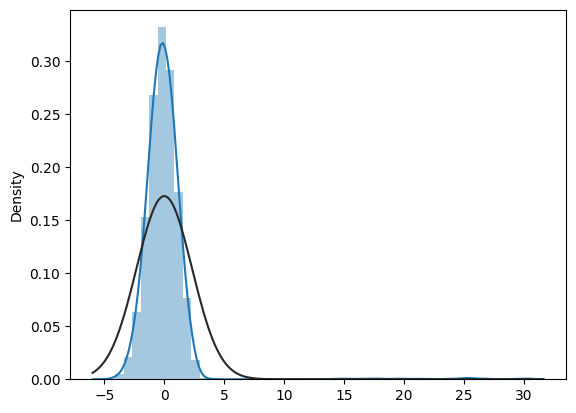

In [63]:
sns.distplot(model1.resid, fit=stats.norm)

Распределение остатков модели статистически значимо отличается от нормального. С одной стороны, такой вывод можно сделать из гистограммы распределение. Распределение остатков характеризуется пиковостью по сравнению с нормальным распределением.

В результате проведения теста на нормальность получили значение p-value ниже уровня значимости 0.05. Нулевая гипотеза отвергается, следовательно, распределение отстатков статистически значимо отличается от нормального.

####Гетероскедастичность

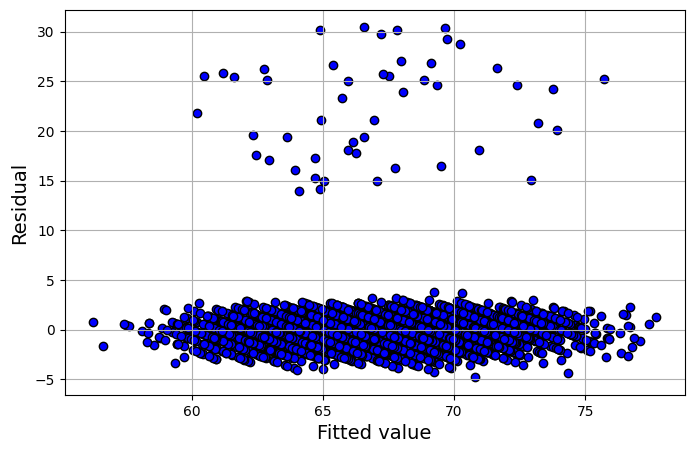

In [64]:
plt.figure(figsize=(8,5))
plt.scatter(x=model1.fittedvalues, y=model1.resid, color='blue', edgecolor='k')
plt.grid(True)
plt.xlabel('Fitted value', fontsize=14)
plt.ylabel('Residual', fontsize=14)
plt.show()

Гетероскедастичность - непостоянство дисперсий остатков. Проблема гетероскедастичности возникает тогда, когда возникает взаимосвязь между остатками и предсказанными значениями. Из диаграммы рассеяния можно заметить, что при всех предсказанных значениях остатки остаются в промежутке между -5 и 5, даже с увеличением значений. Есть некоторые точки, где значения остатков выше, но там они собираются в облако и тоже нельзя проследить взаимосвязи. Следовательно, можно сделать вывод, что проблемы гетероскедастичности здесь не наблюдается.

####Мультиколлинеарность

Несмотря на то, что перед построением модели предикторы были проверены на корреляцию, и между ними не было обнаружено сильной корреляции, еще раз проверим модель на наличие проблемы мультиколлинеарности. Убедимся, что ее нет.

In [65]:
vifs = np.array([vif(model1.model.exog, i) for i in range(model1.model.exog.shape[1])])

In [66]:
vif_df = pd.DataFrame()
vif_df['VIF'] = vifs[1:]
vif_df['Features'] = model1.params.index[1:]
vif_df.sort_values(by=['VIF'])

,VIF,Features
2,1.001832,Attendance
0,1.002868,Hours_Studied
1,1.004536,Previous_Scores
14,1.010082,Tutoring_Sessions_6
13,1.032502,Tutoring_Sessions_5
12,1.087236,Tutoring_Sessions_4
4,1.117721,Motivation_Level_Low
3,1.117900,Motivation_Level_High
7,1.119784,Access_to_Resources_High
8,1.121044,Access_to_Resources_Low


Для каждой независимой переменной-предиктора был рассчитан коэффициент вздутия дисперсии VIF, который показывает силу корреляции каждого предиктора с другими независимыми переменными. Для всех переменных модели значения VIF ниже 10. Значит, можно говорить об отсутствии проблемы с мультиколлинеарностью.

####Выбросы и влияющие наблюдения

In [67]:
influence = model1.get_influence()
inf_sum = influence.summary_frame()
inf_sum

,dfb_const,dfb_Hours_Studied,dfb_Previous_Scores,dfb_Attendance,dfb_Motivation_Level_High,dfb_Motivation_Level_Low,dfb_Family_Income_High,dfb_Family_Income_Low,dfb_Access_to_Resources_High,dfb_Access_to_Resources_Low,...,dfb_Tutoring_Sessions_3,dfb_Tutoring_Sessions_4,dfb_Tutoring_Sessions_5,dfb_Tutoring_Sessions_6,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
0,0.003396,-0.002798,0.001276,-0.001932,-0.000407,-0.008325,0.000044,-0.005853,-0.007800,0.000177,...,-0.000149,-0.000024,-0.000356,0.000048,0.000021,-0.444583,0.001671,-0.018187,-0.444555,-0.018186
1,-0.018338,0.001502,0.011717,0.013982,0.000155,-0.014857,0.008817,0.010776,0.008280,0.008260,...,0.000583,0.000202,-0.000365,-0.000829,0.000076,-0.803371,0.001870,-0.034769,-0.803350,-0.034768
2,-0.007621,0.003073,0.005367,0.007567,-0.003648,-0.003975,-0.004120,-0.005365,-0.004162,-0.003789,...,-0.000122,0.000050,-0.000097,-0.000400,0.000017,0.391123,0.001740,0.016330,0.391098,0.016329
3,0.011260,-0.012537,-0.013841,-0.007467,0.006548,0.007351,0.007802,0.009797,0.007562,0.006288,...,0.007995,0.004909,0.003294,0.002552,0.000056,-0.702192,0.001818,-0.029970,-0.702165,-0.029969
4,-0.000002,-0.000274,-0.001150,0.001944,-0.001515,-0.001646,-0.001676,-0.002028,-0.001506,-0.001368,...,0.004424,-0.000032,-0.000031,-0.000007,0.000003,0.153243,0.001929,0.006737,0.153231,0.006737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,0.004064,0.004574,0.000495,-0.005105,-0.004080,-0.004771,0.010289,0.000054,-0.004918,-0.003909,...,-0.004886,-0.003145,-0.002376,-0.001080,0.000020,0.450820,0.001611,0.018108,0.450793,0.018107
6603,-0.000401,0.003127,0.002831,-0.002271,-0.004918,-0.005658,0.000219,0.007326,-0.005371,-0.004356,...,0.015042,0.000237,-0.000148,-0.000301,0.000029,0.503735,0.001836,0.021605,0.503706,0.021604
6604,-0.001573,0.000069,-0.001621,0.002208,-0.000089,0.003784,0.000077,0.003078,0.000074,0.005141,...,0.006552,-0.000078,0.000180,0.000015,0.000008,0.222018,0.002539,0.011201,0.222002,0.011200
6605,-0.001671,-0.004026,0.002629,0.001245,0.004607,-0.000013,0.000083,0.002685,0.003508,-0.000037,...,0.000022,-0.000040,-0.000073,-0.000005,0.000006,0.198635,0.002414,0.009771,0.198620,0.009770


In [68]:
inf_sum['dffits'][(inf_sum['dffits']>1) | (inf_sum['dffits']<-1)].sort_values()
#потенциальные влияющие наблюдения

,dffits
1525,1.204873


Статистика влияния dffits показывает, как меняется предсказание зависимой переменной, когда наблюдение добавлено или не добавлено в модель. Это значение по модулю больше 1 только для одного наблюдения. Таким образом, искажает предсказательные свойства модели только 1 наблюдение.

In [69]:
inf_sum['standard_resid'][(inf_sum['standard_resid']>3) | (inf_sum['standard_resid']<-3)].sort_values()
#потенциальные выбросы

,standard_resid
2542,6.018576
5125,6.108007
3924,6.459395
4254,6.469947
1607,6.527128
1099,6.618914
5989,6.959545
2076,7.031556
2421,7.142675
1863,7.375900


Вывели список выбросов. Стоит отметить, что среди выбросов нет потенциально влияющего наблюдения, обнаруженного ранее. Попробую удалить выбросы и построить модель без них.

In [70]:
df_filtered = df2.drop(df2[(inf_sum['standard_resid']>3) | (inf_sum['standard_resid']<-3)].index)
#датафрейм, очищенный от выбросов

In [71]:
df_filtered.shape

(6557, 36)

####Модель после удаления выбросов

In [72]:
df_model2 = df_filtered.dropna(subset=['Exam_Score', 'Attendance', 'Hours_Studied', 'Previous_Scores', 'Motivation_Level_High', 'Motivation_Level_Low','Family_Income_High', 'Family_Income_Low', 'Access_to_Resources_High','Access_to_Resources_Low', 'Tutoring_Sessions_0', 'Tutoring_Sessions_2',
       'Tutoring_Sessions_3', 'Tutoring_Sessions_4', 'Tutoring_Sessions_5',
       'Tutoring_Sessions_6'])
df_model2.shape

(6557, 36)

In [73]:
x_mult2 = df_model2[['Hours_Studied', 'Previous_Scores', 'Attendance', 'Motivation_Level_High', 'Motivation_Level_Low','Family_Income_High', 'Family_Income_Low', 'Access_to_Resources_High','Access_to_Resources_Low', 'Tutoring_Sessions_0', 'Tutoring_Sessions_2',
       'Tutoring_Sessions_3', 'Tutoring_Sessions_4', 'Tutoring_Sessions_5',
       'Tutoring_Sessions_6']]
y2 = df_model2['Exam_Score']
x_mult2_constant = sm.add_constant(x_mult2)

In [74]:
model2 = sm.OLS(y2, x_mult2_constant).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     3156.
Date:                Thu, 13 Mar 2025   Prob (F-statistic):               0.00
Time:                        16:19:56   Log-Likelihood:                -10312.
No. Observations:                6557   AIC:                         2.066e+04
Df Residuals:                    6541   BIC:                         2.076e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

####Характеристики новой модели

In [75]:
print('R^2 = {:f}'.format(model2.rsquared))
print('Adj. R^2 = {:f}'.format(model2.rsquared_adj)) #функция из модуля statsmodels
print('F-test significance = {:f}'.format(model2.f_pvalue))

R^2 = 0.878616
Adj. R^2 = 0.878337
F-test significance = 0.000000


После удаления выбросов качество модели повысилось. Теперь независимые переменные объясняют 87,9% дисперсии независимой переменной. Rˆ2 стал заметно выше по сравнению с предыдущей моделью (где значение Rˆ2 = 0.647).

F-test significance < 0.05, модель по-прежнему остается статистически значимой.

In [76]:
true_values = df_model2['Exam_Score']
predicted_values = model2.fittedvalues
mae = mean_absolute_error(true_values, predicted_values)
print('Mean Absolute Error:', mae)

Mean Absolute Error: 0.9341180351443127


Значение средней абсолютной ошибки снизилось (в первом случае MAE = 1.106). Модель теперь допускает меньше ошибок в предсказании значений.

In [77]:
true_values = df_model2['Exam_Score']
predicted_values =  model2.fittedvalues
mse = mean_squared_error(true_values, predicted_values)
print('Mean Squared Error:', mse)

Mean Squared Error: 1.3600447591009561


Сильно снизился показатель средней квадратичной ошибки (1.36 по сравнению с 5.34). Модель после удаления выбросов допускает меньше больших ошибок.

In [78]:
true_values = df_model2['Exam_Score']
predicted_values =  model2.fittedvalues

rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
print('Root Mean Squared Error (RMSE):', rmse)

Root Mean Squared Error (RMSE): 1.1662095691173848


Показатель RMSE значительно сократился (1.166 по сравнению с 2.31 для прошлой модели). Снижение Mean Squared Error и Root Mean Squared Error более значительное, чем Mean Absolute Error, что свидетельствует о том, что удалось исключить большие ошибки.

##Задание 5

5. Сформулируйте общие содержательные выводы по результатам регрессионного анализа данных. Какие результаты анализа данных для вас оказались очевидными, а какие неожиданными?

По итогам регрессионного анализа была построена модель, которая показывает взаимосвязь между оценкой, полученной студентами на экзамене и выбранными предикторами. Данная модель может предсказывать балл студента на основе ряда факторов.

Модель множественной регрессии со стандартизированными коэффициентами показывает, что текущий балл за экзамен в наибольшей степени взаимосвязан с процентом занятий, которые студент посетил за месяц, а вторым по важности фактором является количество часов, которые студенты посвятили учебе. Чем выше процент посещенных занятий и часов, которые тратили на обучение, тем более высокий балл был получен. Регрессионная модель с нестандартизированными коэффициентами показала, на какое количество баллов увеличивается результат студентов с увеличением, например, посещаемости на 1% или количество часов за учебой на 1 час.

В модель были включены категориальные предикторы. На основе сводных таблиц и ящиков с усами выяснили, где можно пронаблюдать значимые различия в баллах за экзамен в каждой категории. Можно было проследить значимые различия в результатах в зависимости от уровня мотивации к учебе, уровня дохода семей, доступа к образовательным ресурсам, количества посещенных репетиторских занятий за месяц. Модель регрессии со стандартизированными коэффициентами показала, что сильное влияние на зависимую переменную оказывает доступ к ресурсам. На результат сильно влияет (по модулю), что студент имеет высокий уровень доступа к ресурсам по сравнению со средним, а также что студент имеет низкий уровень доступа к ресурсам по сравнению со средним.

Ожидала, что:

- результат экзамена будет сильно зависеть от количества часов, которое студенты посвятили учебе

- посещение занятий оказывает значительное влияние на результат по экзамену

Тем не менее, я предполагала, что важность количества часов, затрачиваемых на обучение, выше, чем посещаемость занятий с точки зрения влияния на результат.

- посещение репетиторских занятий будет оказывать влияние на результат с той точки зрения, что чем больше занятий посещает студент, тем лучше он пишет экзамен.

Неожиданным было, что уже на этапах предварительного анализа данных нельзя было отметить различий в результатах в зависимости от пола студентов. Поэтому переменная не была использована в модели. Удивило то, что нельзя отметить существенных различий в результатах экзамена в зависимости от качества преподавания. Также интересно, что на результаты текущего экзамена влияют также результаты, полученные на прошлом экзамене. Студент не может резко хуже писать экзамен (или резко лучше) по сравнению со своим прошлым результатом. При увеличении результата за прошлым экзамен на 1 балл, результат за текущий будет больше на 0.05 балла.

Комментарии к заданию и принципам его оценивания:

 - Все пункты задания должны сопровождаться выполненным фрагментом кода. В этом задании будет проверяться корректность работы кода, то есть будут последовательно запущены ячейки, чтобы убедиться, что код не выдаст ошибку в какой-то момент. Перед отправкой работы на проверку рекомендуется "прогнать" код.
 - Если Вы получили результаты в виде статистических показателей, таблиц или графиков, при этом никак их не прокомментировали и не сформулировали содержательные выводы на их основе, то работа оценивается в 0 баллов, в этом случае анализ данных не проведён.
 - Если Вы полностью выполнили это задание, то получаете за него 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть дополнительное самостоятельное изучение инструментов регрессионного анализа и их применение, или развернутое и глубокое исследование имеющихся данных на основе использования пройденных на занятиях методов.
 - В этом задании 5 пунктов. Первый весит 15%, второй - 20%, третий - 40%, четвертый - 20%, пятый - 5%.
 - Задание можно выполнять на русском или на английском языке, критерии оценивания при этом не меняются (прошу удалять из работы текст, написанный на иных языках);
 - Задание можно выполнять индивидуально или в группе из 2 человек, критерии оценивания при этом не меняются;
 - В названии загружаемого в Smart LMS файла нужно указать фамилию(ии) автора(ов) работы.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 13:00 14 марта. Не рекомендую загружать файл в Smart LMS в последние несколько минут перед дедлайном. После дедлайна выполненные задания не принимаются.